In [1]:
# Python Libraries for Data Analysis

# Import necessary libraries for data analysis
import numpy as np  # Numerical computations and array manipulation
import pandas as pd  # Data manipulation and analysis
import matplotlib.pyplot as plt  # Plotting and visualization
import seaborn as sns  # Statistical data visualization
import scipy  # Scientific and technical computing
import statsmodels.api as sm  # Statistical modeling and hypothesis testing
from sklearn import datasets  # Machine learning algorithms and tools
import plotly.express as px  # Interactive visualizations
import xlrd  # Reading Excel files
import openpyxl  # Reading and writing Excel files
import json  # Working with JSON data
import csv  # Handling CSV files
import os

In [2]:
os.getcwd()

'c:\\Users\\Aleja\\OneDrive\\Desktop\\Going Back\\00-First Test'

In [3]:
os.listdir()

['00-Libraries Test.ipynb',
 '01-A1.ipynb',
 '02-Product Table.ipynb',
 '03-Sales.ipynb',
 '04-Number_One_Is_Back.ipynb',
 '05-Charts.ipynb',
 'ArchivosGenerados',
 'HTML.html',
 'Prueba_Ventas01.csv']

In [4]:
os.chdir("ArchivosGenerados")

In [5]:
os.listdir()

['CSV', 'Power BI', 'XLSX']

In [6]:
os.chdir("CSV")

In [7]:
os.listdir()

['Datos_Prueba.csv',
 'First_Test.csv',
 'First_Test2.csv',
 'First_Test3.csv',
 'products_table.csv',
 'products_table2.csv',
 'Prueba_Ventas01.csv']

In [8]:
Datos_Prueba = pd.read_csv("Datos_Prueba.csv")

In [10]:
Datos_Prueba.head()

,Date,Month,Quarter,Quarter_Year,Id_Client,Client_Name,Id_Sale,Id_Product,Product_Name,Id_Product_Type,Units,Unit_Cost,Margin_Applied,Unit_Price,Total_Amount,Shipping_Method,Payment_Status,Shipping_Date
0,04-12-2024,April,Q2,Q2-2024,63,Client_63,2341,880,Product_880,2,90,355.52,0.12,398.18,35836.20,Standard,Credit Card,04-15-2024
1,03-11-2025,March,Q1,Q1-2025,84,Client_84,1794,876,Product_876,3,19,63.59,0.06,67.41,1280.79,Standard,Credit Card,03-14-2025
2,09-27-2024,September,Q3,Q3-2024,25,Client_25,2297,316,Product_316,20,50,405.66,0.23,498.96,24948.00,Overnight,Cash,10-05-2024
3,04-16-2024,April,Q2,Q2-2024,12,Client_12,2293,734,Product_734,48,68,200.82,0.15,230.94,15703.92,Overnight,Cash,04-25-2024
4,03-12-2024,March,Q1,Q1-2024,21,Client_21,2171,862,Product_862,44,5,328.09,0.46,479.01,2395.05,Standard,Cash,03-17-2024


In [11]:
Datos_Prueba.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             10000 non-null  str    
 1   Month            10000 non-null  str    
 2   Quarter          10000 non-null  str    
 3   Quarter_Year     10000 non-null  str    
 4   Id_Client        10000 non-null  int64  
 5   Client_Name      10000 non-null  str    
 6   Id_Sale          10000 non-null  int64  
 7   Id_Product       10000 non-null  int64  
 8   Product_Name     10000 non-null  str    
 9   Id_Product_Type  10000 non-null  int64  
 10  Units            10000 non-null  int64  
 11  Unit_Cost        10000 non-null  float64
 12  Margin_Applied   10000 non-null  float64
 13  Unit_Price       10000 non-null  float64
 14  Total_Amount     10000 non-null  float64
 15  Shipping_Method  10000 non-null  str    
 16  Payment_Status   10000 non-null  str    
 17  Shipping_Date    10000 n

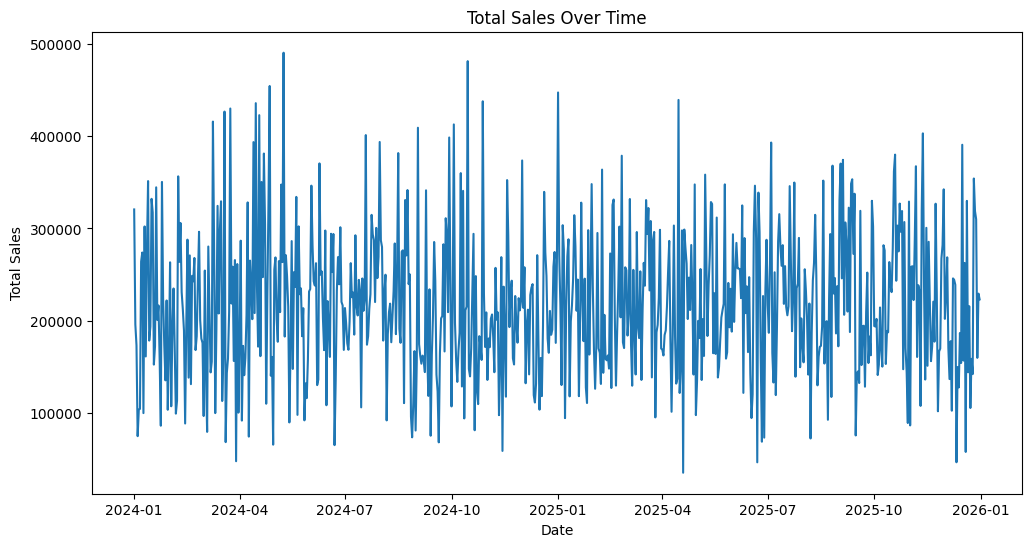

In [12]:
# Convert 'Date' to datetime
Datos_Prueba['Date'] = pd.to_datetime(Datos_Prueba['Date'])

# Aggregate total sales by date
sales_over_time = Datos_Prueba.groupby('Date')['Total_Amount'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=sales_over_time, x='Date', y='Total_Amount')
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()


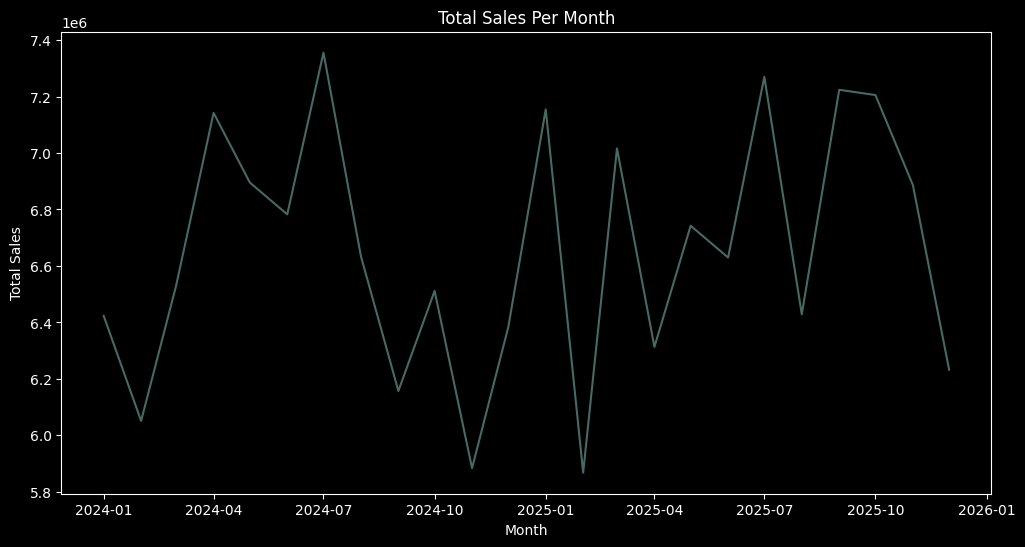

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Date' to datetime
Datos_Prueba['Date'] = pd.to_datetime(Datos_Prueba['Date'])

# Extract year and month to create a new column
Datos_Prueba['YearMonth'] = Datos_Prueba['Date'].dt.to_period('M')

# Aggregate total sales by YearMonth
sales_per_month = Datos_Prueba.groupby('YearMonth')['Total_Amount'].sum().reset_index()

# Convert 'YearMonth' back to datetime for plotting
sales_per_month['YearMonth'] = sales_per_month['YearMonth'].dt.to_timestamp()

# Set plot style to dark background
plt.style.use('dark_background')

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 6))

# Plot with seaborn, passing the axes
sns.lineplot(data=sales_per_month, x='YearMonth', y='Total_Amount', alpha=0.5, ax=ax)

# Optional: customize grid, labels, title for better visibility
ax.set_title('Total Sales Per Month', color='white')
ax.set_xlabel('Month', color='white')
ax.set_ylabel('Total Sales', color='white')
ax.tick_params(colors='white')  # Change tick color to white

# Show plot
plt.show()



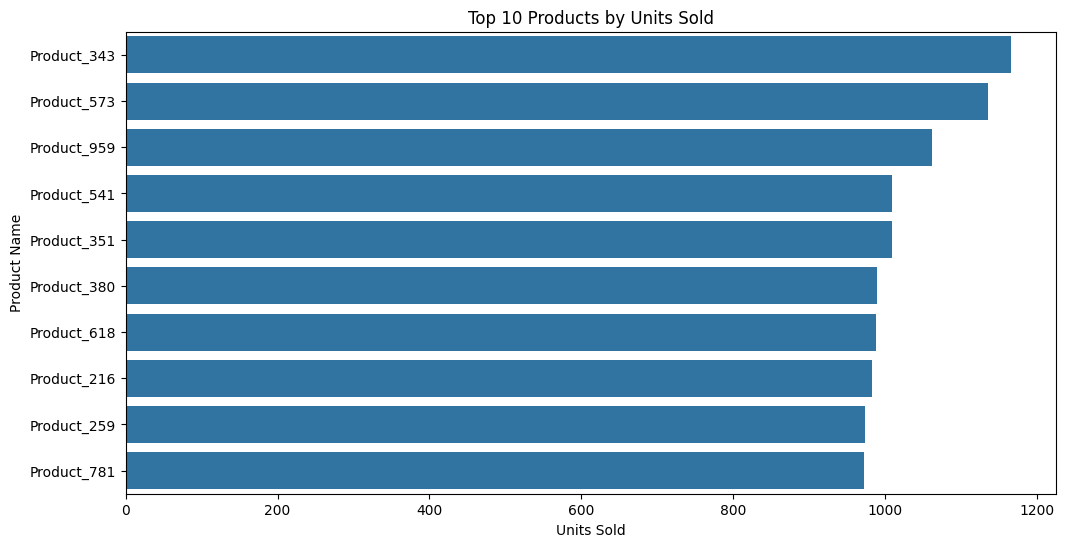

C:\Users\Aleja\AppData\Local\Temp\ipykernel_17288\490167614.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=filtered_shipping_sales.values, y=filtered_shipping_sales.index, palette=color_list)


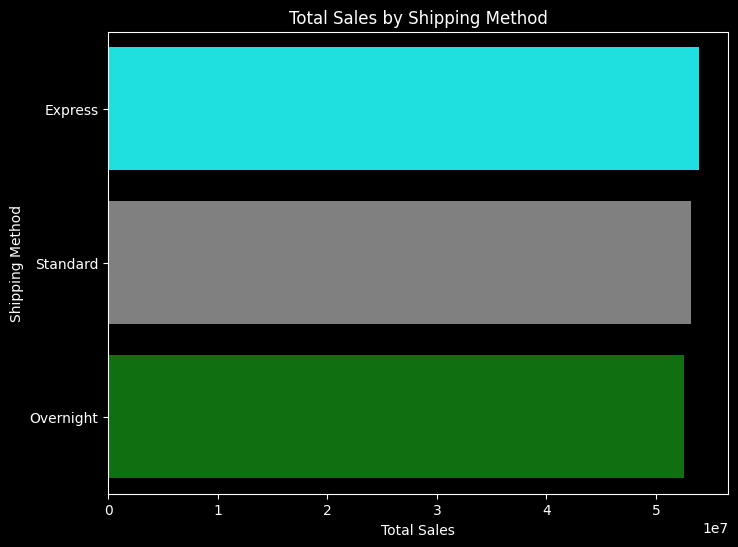

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total sales per shipping method
shipping_sales = Datos_Prueba.groupby('Shipping_Method')['Total_Amount'].sum().sort_values(ascending=False)

# Filter shipping methods if needed (e.g., only specific methods)
# For example, suppose we want only certain methods:
desired_methods = ['Standard', 'Express', 'Overnight']
filtered_shipping_sales = shipping_sales[shipping_sales.index.isin(desired_methods)]

# Store the filtered methods in a variable
shipping_methods = filtered_shipping_sales.index.tolist()

# Define a color for each shipping method
colors = {
    'Standard': 'Grey',
    'Express': 'cyan',
    'Overnight': 'green'
}

# Prepare color list in order of shipping_methods
color_list = [colors[method] for method in shipping_methods]

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x=filtered_shipping_sales.values, y=filtered_shipping_sales.index, palette=color_list)
plt.title('Total Sales by Shipping Method')
plt.xlabel('Total Sales')
plt.ylabel('Shipping Method')
plt.show()



C:\Users\Aleja\AppData\Local\Temp\ipykernel_17288\956054941.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


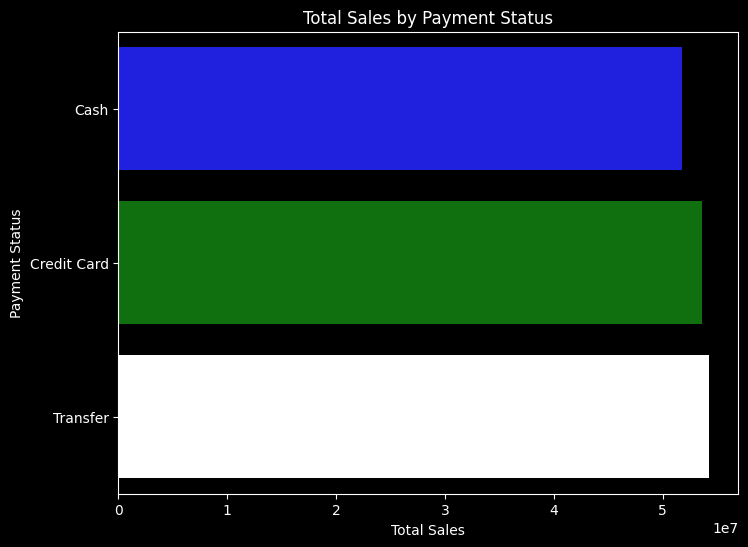

In [37]:
# Define payment methods
payment_method1 = 'Credit Card'
payment_method2 = 'Cash'
payment_method3 = 'Bank Transfer'

# Assign a color to each payment method
color_credit_card = 'blue'
color_cash = 'green'
color_bank_transfer = 'white'

# Example: Filter data if needed (assuming 'Payment_Method' column exists)
# Filter data for each payment method
# data_credit_card = Datos_Prueba[Datos_Prueba['Payment_Method'] == payment_method1]
# data_cash = Datos_Prueba[Datos_Prueba['Payment_Method'] == payment_method2]
# data_bank_transfer = Datos_Prueba[Datos_Prueba['Payment_Method'] == payment_method3]

# Summing total amounts by payment status (as in your original code)
payment_sales = Datos_Prueba.groupby('Payment_Status')['Total_Amount'].sum()

# Plotting with specified colors for each payment method
plt.figure(figsize=(8,6))
sns.barplot(
    x=payment_sales.values,
    y=payment_sales.index,
    palette=[color_credit_card, color_cash, color_bank_transfer]
)
plt.title('Total Sales by Payment Status')
plt.xlabel('Total Sales')
plt.ylabel('Payment Status')
plt.show()



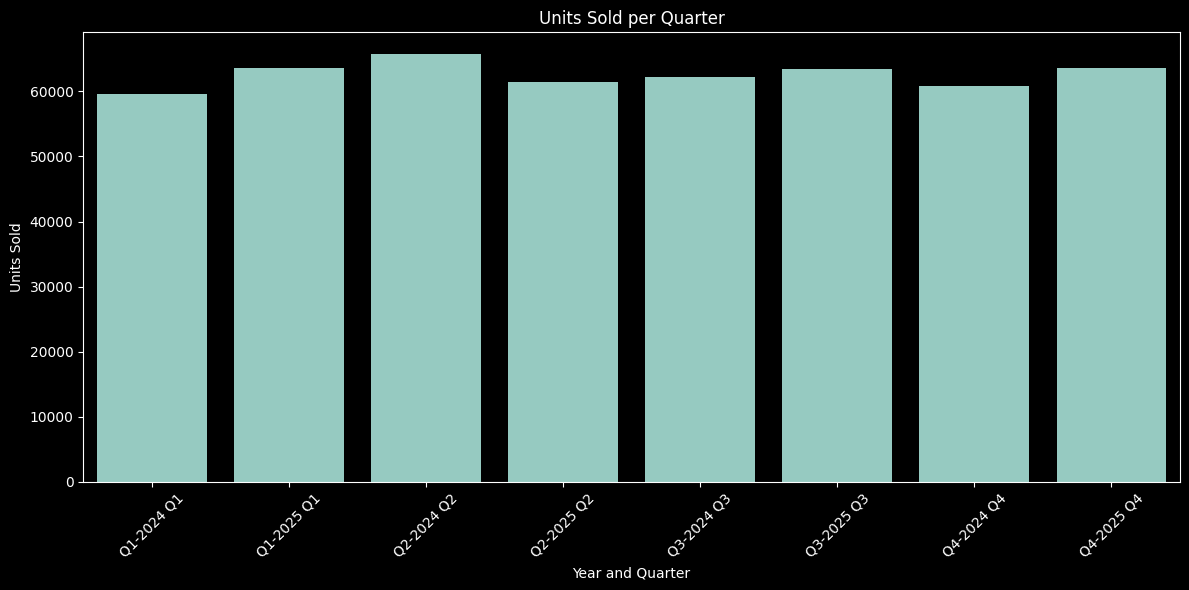

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por año y trimestre para sumar las unidades vendidas
quarterly_units = Datos_Prueba.groupby(['Quarter_Year', 'Quarter'])['Units'].sum().reset_index()

# Crear una columna para combinar año y trimestre en un solo string para facilitar la visualización
quarterly_units['Year_Quarter'] = quarterly_units['Quarter_Year'] + ' ' + quarterly_units['Quarter']

# Ordenar los datos por año y trimestre
quarter_order = ['Q1', 'Q2', 'Q3', 'Q4']
quarterly_units['Quarter'] = pd.Categorical(quarterly_units['Quarter'], categories=quarter_order, ordered=True)
quarterly_units = quarterly_units.sort_values(['Quarter_Year', 'Quarter'])

# Visualizar
plt.figure(figsize=(12,6))
sns.barplot(x='Year_Quarter', y='Units', data=quarterly_units)
plt.title('Units Sold per Quarter')
plt.xlabel('Year and Quarter')
plt.ylabel('Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



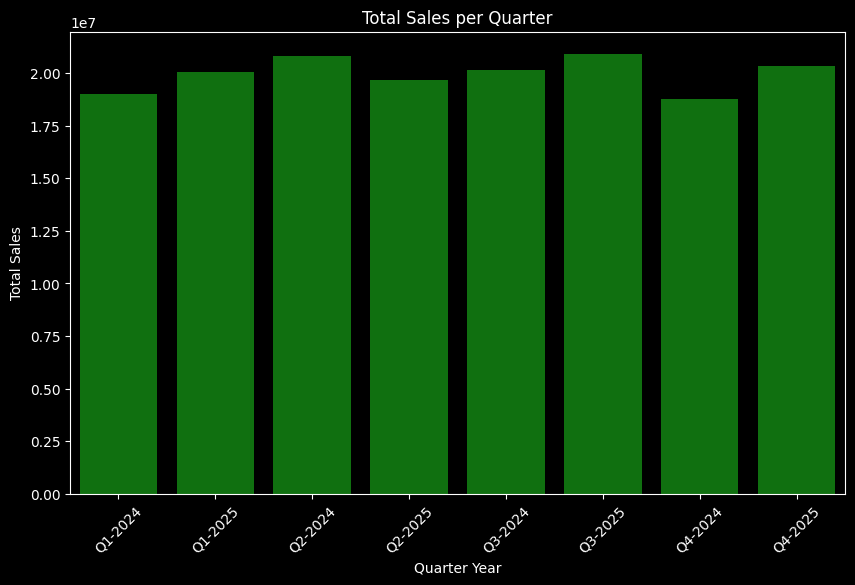

In [39]:
quarter_sales = Datos_Prueba.groupby('Quarter_Year')['Total_Amount'].sum()

plt.figure(figsize=(10,6))
sns.barplot(x=quarter_sales.index, y=quarter_sales.values, color='green')
plt.title('Total Sales per Quarter')
plt.xlabel('Quarter Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

